# STEP 1: DATA PREPROCESSING
Sab se pehle hum data preprocessing karenge. Raw data mein bohot noise hota hai, isliye hum usay clean karenge taake model achi tarah train ho sake.

In [15]:
!pip install langdetect

## Import Necessary Libraries
Yahan hum zaroori libraries import kar rahe hain jaise pandas data ke liye, nltk text processing ke liye, or sklearn model training ke liye.

In [16]:
import re
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, f1_score, classification_report
print('Finish importing libraries')

Finish importing libraries


### Exploratory Data Analysis (EDA)
Ab hum EDA (Exploratory Data Analysis) karenge taake hum dekh saken ke hamare dataset mein kitni classes hain, data balanced hai ya nahi, aur text ki length kya hai.

In [17]:
import pandas as pd
from pathlib import Path
import os

# Define Paths
RAW_CSV = Path("/content/mbti_1.csv")
OUT_ROOT = Path("/content/working")
REPORTS = OUT_ROOT / "reports"
RANDOM_SEED = 42

# Create Directories
for d in [OUT_ROOT, REPORTS]:
    d.mkdir(parents=True, exist_ok=True)

# LOAD DATA
if not RAW_CSV.exists():
    print(f"Error: {RAW_CSV} not found in /content/.")
    print("Please upload the file using the sidebar or run the download cell below.")
else:
    df = pd.read_csv(RAW_CSV)
    print("Loaded:", RAW_CSV, "shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

Loaded: /content/mbti_1.csv shape: (8675, 2)
Columns: ['type', 'posts']


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


### 1. DATA QUALITY CHECKS

In [18]:
missing_counts = df.isna().sum()
if missing_counts.any():
    print("Missing values per column:")
    print(missing_counts[missing_counts > 0])
else:
    print("No missing values.")
dup_full = df.duplicated().sum()
print(f"Duplicate full rows: {dup_full}")
if 'posts' in df.columns:
    dup_posts = df['posts'].duplicated().sum()
    print(f"Duplicate 'posts' content: {dup_posts}")
try:
    DetectorFactory.seed = RANDOM_SEED

    sample = df['posts'].dropna().sample(min(50, len(df)), random_state=RANDOM_SEED)
    non_english = []
    for t in sample:
        try:
            if detect(str(t)) != "en":
                non_english.append(t)
        except:
            non_english.append(t)
    if non_english:
        print(f"Found {len(non_english)} non-English samples in a sample of 50.")
    else:
        print("All sample posts are detected as English.")
except ImportError:
    print("langdetect not installed, skipping language check.")

print("DONE QUALITY CHECKS \n")

No missing values.
Duplicate full rows: 0
Duplicate 'posts' content: 0
All sample posts are detected as English.
DONE QUALITY CHECKS 



### 2. FEATURE ENGINEERING (text-based stats)

In [19]:
if 'text' not in df.columns:
    if 'posts' in df.columns:
        df['text'] = df['posts'].astype(str)
    else:
        raise ValueError("Input CSV must include 'posts' or 'text' column")

#### Post count

In [20]:
def count_posts_field(s):
    s = str(s)
    return s.count('|||') + 1 if s.strip() != '' else 0

df['post_count'] = df['posts'].apply(count_posts_field)

#### Length & punctuation / URL / emoji counts

In [21]:
df['text_len_chars'] = df['text'].astype(str).apply(len)
df['text_len_words'] = df['text'].astype(str).apply(lambda s: len(str(s).split()))
url_re = re.compile(r'http\S+|www\.\S+')
df['n_urls'] = df['text'].astype(str).apply(lambda s: len(url_re.findall(s)))
df['n_q'] = df['text'].astype(str).apply(lambda s: s.count('?'))
df['n_excl'] = df['text'].astype(str).apply(lambda s: s.count('!'))
df['n_nonascii_chars'] = df['text'].astype(str).apply(lambda s: sum(1 for ch in s if ord(ch) > 127))
df['frac_ascii_chars'] = df['text'].astype(str).apply(lambda s: sum(1 for ch in s if ord(ch) < 128) / max(1, len(s)))
print("DONE FEATURE EGINEERING")

DONE FEATURE EGINEERING


### 3. MBTI axes extraction (IE, SN, TF, JP)

In [22]:
if 'type' not in df.columns:
    raise ValueError("Input CSV must contain 'type' column with MBTI labels (e.g. INTP)")

def axes_from_type(t):
    s = str(t).strip().upper()
    s = (s + "XXXX")[:4]
    return pd.Series({
        'IE': 1 if s[0] == 'I' else 0,
        'SN': 1 if s[1] == 'N' else 0,
        'TF': 1 if s[2] == 'T' else 0,
        'JP': 1 if s[3] == 'J' else 0
    })

axes_df = df['type'].apply(axes_from_type)
df = pd.concat([df, axes_df], axis=1)


### 4. Distributions & summary stats

In [23]:
type_counts = df['type'].value_counts().sort_values(ascending=False)
axis_counts = {
    'I': int(df['IE'].sum()),
    'E': int((df['IE'] == 0).sum()),
    'N': int(df['SN'].sum()),
    'S': int((df['SN'] == 0).sum()),
    'T': int(df['TF'].sum()),
    'F': int((df['TF'] == 0).sum()),
    'J': int(df['JP'].sum()),
    'P': int((df['JP'] == 0).sum())
}

summary = {
    "n_samples": int(len(df)),
    "unique_mbti_types": int(df['type'].nunique()),
    "top_mbti_counts": type_counts.head(12).to_dict(),
    "axis_counts": axis_counts,
    "text_len_chars_mean": float(df['text_len_chars'].mean()),
    "text_len_chars_median": float(df['text_len_chars'].median()),
    "text_len_words_mean": float(df['text_len_words'].mean()),
    "text_len_words_median": float(df['text_len_words'].median()),
    "avg_urls_per_user": float(df['n_urls'].mean()),
    "avg_questions_per_user": float(df['n_q'].mean()),
    "avg_exclaims_per_user": float(df['n_excl'].mean()),
    "avg_nonascii_per_user": float(df['n_nonascii_chars'].mean()),
    "avg_frac_ascii": float(df['frac_ascii_chars'].mean())
}
print(json.dumps(summary, indent=2))

# --- Save EDA table summary CSV ---
eda_table = df[['type','post_count','text_len_chars','text_len_words','n_urls','n_q','n_excl','n_nonascii_chars','frac_ascii_chars']].copy()
eda_table.to_csv(REPORTS / "eda_table_summary.csv", index=False)


{
  "n_samples": 8675,
  "unique_mbti_types": 16,
  "top_mbti_counts": {
    "INFP": 1832,
    "INFJ": 1470,
    "INTP": 1304,
    "INTJ": 1091,
    "ENTP": 685,
    "ENFP": 675,
    "ISTP": 337,
    "ISFP": 271,
    "ENTJ": 231,
    "ISTJ": 205,
    "ENFJ": 190,
    "ISFJ": 166
  },
  "axis_counts": {
    "I": 6676,
    "E": 1999,
    "N": 7478,
    "S": 1197,
    "T": 3981,
    "F": 4694,
    "J": 3434,
    "P": 5241
  },
  "text_len_chars_mean": 7234.98962536023,
  "text_len_chars_median": 7515.0,
  "text_len_words_mean": 1226.2414985590779,
  "text_len_words_median": 1278.0,
  "avg_urls_per_user": 2.875734870317003,
  "avg_questions_per_user": 10.730951008645533,
  "avg_exclaims_per_user": 8.454293948126802,
  "avg_nonascii_per_user": 1.0863400576368876,
  "avg_frac_ascii": 0.9998354393479015
}


### 5. Plots

In [24]:
plt.figure(figsize=(12,5))
type_counts.plot(kind='bar')
plt.title("MBTI 16-class distribution")
plt.xlabel("MBTI type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(REPORTS / "mbti_type_dist.png")
plt.close()

plt.figure(figsize=(7,3))
keys = ['I','E','N','S','T','F','J','P']
vals = [axis_counts[k] for k in keys]
plt.bar(keys, vals)
plt.title("MBTI axis distribution (counts)")
plt.tight_layout()
plt.savefig(REPORTS / "mbti_axis_dist.png")
plt.close()

plt.figure(figsize=(6,3))
plt.hist(df['text_len_words'].clip(upper=400), bins=50)
plt.title("Distribution of total words per user (clipped at 400)")
plt.xlabel("words")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(REPORTS / "text_length_hist.png")
plt.close()

### 6. Mask sample text and save

In [25]:
def mask_pii(text, char_limit=800):
    if pd.isnull(text):
        return ""
    t = re.sub(r'http\S+|www\.\S+|\.com\S+|\S+@\S+', '<PII>', str(text))
    return t[:char_limit].replace('\n', ' ')

sample_masked = df.sample(4, random_state=RANDOM_SEED)[['type','text']].copy()
sample_masked['masked'] = sample_masked['text'].apply(mask_pii)
sample_masked.to_csv(REPORTS / "sample_masked_examples.csv", index=False)

print("\nMasked sample posts (first 2):")
for i, row in sample_masked.head(2).iterrows():
    print(f"[{row['type']}] {row['masked'][:400]}\n")

print("EDA CSV and plots saved to:", REPORTS)
print("Done.")


Masked sample posts (first 2):
[INTP] 'This. When I lie it's to avoid an unreasonable response for something I did that was completely justifiable to me but if I was to try to justify to someone else they'd be too hung up on what I did. I...|||Your IQ (SD15): 128|||I typically have very difficult times maintaining friends I've come to realize. I've had people I talk to for years and I still don't want to talk to them... I DID, but the

[INTJ] 'I said zero flexibility and little time for dating. Going around sifting through dates to find one that clicks isn't going to be as viable.  That has nothing to do with maintaining a relationship I...|||How you've come to the conclusion I have nothing to offer  merely because I am busy is beyond me.       No not really. Again, more made up stuff.|||okay, this isn't cool.  you're specifically look

EDA CSV and plots saved to: /content/working/reports
Done.


#### Remove URL, emoji, special chars, lowercase

In [26]:
def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text
df["clean_step1"] = df["text"].apply(basic_clean)
df[["text", "clean_step1"]].sample(5, random_state=42)

,text,clean_step1
2802,'This. When I lie it's to avoid an unreasonabl...,this when i lie it s to avoid an unreasonabl...
2166,'I said zero flexibility and little time for d...,i said zero flexibility and little time for d...
1919,'This has to be written with bias or something...,this has to be written with bias or something...
360,'HAuhuHAuh You might be right Muhicz. I'm just...,hauhuhauh you might be right muhicz i m just...
1115,'Her parents are kind of the go to college = g...,her parents are kind of the go to college g...


## Tokenize
Ab hum text ko "Tokenize" karenge, yani har jumlay (sentence) ko alag alag words mein torenge.

In [27]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')

df["clean_step2"] = df["clean_step1"].apply(word_tokenize)
df[["clean_step1", "clean_step2"]].sample(5, random_state=42)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,clean_step1,clean_step2
2802,this when i lie it s to avoid an unreasonabl...,"[this, when, i, lie, it, s, to, avoid, an, unr..."
2166,i said zero flexibility and little time for d...,"[i, said, zero, flexibility, and, little, time..."
1919,this has to be written with bias or something...,"[this, has, to, be, written, with, bias, or, s..."
360,hauhuhauh you might be right muhicz i m just...,"[hauhuhauh, you, might, be, right, muhicz, i, ..."
1115,her parents are kind of the go to college g...,"[her, parents, are, kind, of, the, go, to, col..."


## Stopwords
Hum "Stopwords" remove karenge. Ye wo alfaz hain jo sentence mein grammar ke liye use hote hain magar unka koi khaas meaning nahi hota (jaise "is", "the", "and").

In [28]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
df["clean_step3"] = df["clean_step2"].apply(lambda tokens: [w for w in tokens if w not in stop_words])
df[["clean_step2", "clean_step3"]].sample(5, random_state=42)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,clean_step2,clean_step3
2802,"[this, when, i, lie, it, s, to, avoid, an, unr...","[lie, avoid, unreasonable, response, something..."
2166,"[i, said, zero, flexibility, and, little, time...","[said, zero, flexibility, little, time, dating..."
1919,"[this, has, to, be, written, with, bias, or, s...","[written, bias, something, sure, could, even, ..."
360,"[hauhuhauh, you, might, be, right, muhicz, i, ...","[hauhuhauh, might, right, muhicz, wondering, s..."
1115,"[her, parents, are, kind, of, the, go, to, col...","[parents, kind, go, college, good, job, people..."


## Lemmatization
Lemmatization ka matlab hai words ko unki root form mein lana (jaise "running" ko "run" banana). Is se model ko words samajhne mein asani hoti hai.

In [29]:
nltk.download("wordnet")
nltk.download("omw-1.4")
lemmatizer = WordNetLemmatizer()
df["clean_step4"] = df["clean_step3"].apply(lambda tokens: [lemmatizer.lemmatize(w) for w in tokens])
df["clean_step4"] = df["clean_step4"].apply(lambda tokens: " ".join(tokens))
df[["clean_step3", "clean_step4"]].sample(5, random_state=42)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,clean_step3,clean_step4
2802,"[lie, avoid, unreasonable, response, something...",lie avoid unreasonable response something comp...
2166,"[said, zero, flexibility, little, time, dating...",said zero flexibility little time dating going...
1919,"[written, bias, something, sure, could, even, ...",written bias something sure could even say tru...
360,"[hauhuhauh, might, right, muhicz, wondering, s...",hauhuhauh might right muhicz wondering step co...
1115,"[parents, kind, go, college, good, job, people...",parent kind go college good job people want st...


## Label Encoding
### Converting MBTI Types to Binary Labels
MBTI ke 16 types hote hain. Hum unhein 4 binary axes (0 ya 1) mein convert karenge taake hum multi-output classification kar saken (Example: I vs E, N vs S).

In [30]:
def mbti_to_binary(mbti_type):
    """
    Chuyển MBTI string (ví dụ: INFJ) thành 4 binary labels.
    I/E, N/S, T/F, J/P -> 0/1
    """
    return pd.Series({
        "IE": 1 if mbti_type[0] == "I" else 0,   # I=1, E=0
        "SN": 1 if mbti_type[1] == "N" else 0,   # N=1, S=0
        "TF": 1 if mbti_type[2] == "T" else 0,   # T=1, F=0
        "JP": 1 if mbti_type[3] == "J" else 0    # J=1, P=0
    })

for col in ["IE", "SN", "TF", "JP"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

y = df["type"].apply(mbti_to_binary)
df = pd.concat([df, y], axis=1)

df[["type", "IE", "SN", "TF", "JP", "clean_step4"]].sample(5, random_state=42)


,type,IE,SN,TF,JP,clean_step4
2802,INTP,1,1,1,0,lie avoid unreasonable response something comp...
2166,INTJ,1,1,1,1,said zero flexibility little time dating going...
1919,INTP,1,1,1,0,written bias something sure could even say tru...
360,ENFP,0,1,0,0,hauhuhauh might right muhicz wondering step co...
1115,ENTJ,0,1,1,1,parent kind go college good job people want st...


### Train/Test Split
Hum apne data ko 3 hisson mein divide karenge:

Train: Model ko sikhane ke liye.

Validation: Training ke doran check karne ke liye.

Test: Final result check karne ke liye.

In [31]:
X = df["clean_step4"].astype(str)
y = df[["IE", "SN", "TF", "JP"]]

# Split Train (70%), Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y["IE"]
)

# Split Train (70%), Temp (30%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp["IE"]
)

print("Train size:", X_train.shape[0])
print("Valid size:", X_valid.shape[0])
print("Test size:",  X_test.shape[0])

train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
valid_df = pd.concat([X_valid.reset_index(drop=True), y_valid.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)

train_df.rename(columns={"clean_step4": "text"}, inplace=True)
valid_df.rename(columns={"clean_step4": "text"}, inplace=True)
test_df.rename(columns={"clean_step4": "text"}, inplace=True)

OUTPUT_DIR = "/content/split_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
valid_df.to_csv(os.path.join(OUTPUT_DIR, "valid.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)

print("Saved train/valid/test splits to:", OUTPUT_DIR)
train_df.sample(3, random_state=42)


Train size: 6072
Valid size: 1301
Test size: 1302
Saved train/valid/test splits to: /content/split_data


,text,IE,SN,TF,JP
5213,google intp came sorry hate picture post cuz g...,1,1,1,0
5322,thanks guy admittedly trained persistent abuse...,0,1,1,1
1657,also labelling hate group hate speech e people...,1,1,1,0


# STEP 2: FEATURE EXTRACTION (TF-IDF)
Machine learning models text nahi samajhte, numbers samajhte hain. Isliye hum TF-IDF use karke text ko numbers (vectors) mein convert karenge.

### TF-IDF for word-level

In [32]:
tfidf_word = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    max_features=20000,
    stop_words="english"
)

### TF-IDF for char-level

In [33]:
tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=30000
)

### Fit + Transform

In [34]:
X_train_word = tfidf_word.fit_transform(X_train)
X_valid_word = tfidf_word.transform(X_valid)
X_test_word  = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_valid_char = tfidf_char.transform(X_valid)
X_test_char  = tfidf_char.transform(X_test)

### Combine word + char features

In [35]:
from scipy.sparse import hstack
X_train_tfidf = hstack([X_train_word, X_train_char])
X_valid_tfidf = hstack([X_valid_word, X_valid_char])
X_test_tfidf  = hstack([X_test_word,  X_test_char])

print("TF-IDF shapes:")
print("Train:", X_train_tfidf.shape)
print("Valid:", X_valid_tfidf.shape)
print("Test:",  X_test_tfidf.shape)
feature_names = tfidf_word.get_feature_names_out()
import numpy as np
idf_scores = tfidf_word.idf_
top_common = sorted(zip(feature_names, idf_scores), key=lambda x: x[1])[:10]

pd.DataFrame(top_common, columns=["Feature", "IDF"]).head(10)


TF-IDF shapes:
Train: (6072, 50000)
Valid: (1301, 50000)
Test: (1302, 50000)


,Feature,IDF
0,like,1.013261
1,think,1.038266
2,people,1.043756
3,know,1.053784
4,time,1.057439
5,thing,1.076099
6,really,1.096562
7,make,1.117824
8,way,1.147913
9,say,1.156156


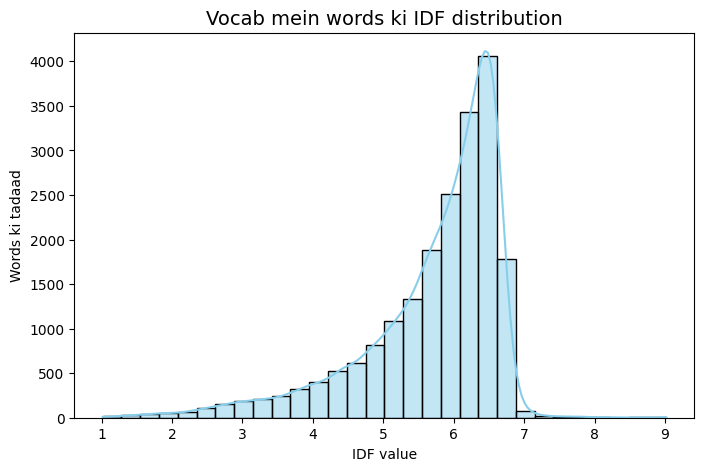


🔹 Top 10 sab se common words (Low IDF):


,Feature,IDF
9144,like,1.013261
17115,think,1.038266
12072,people,1.043756
8557,know,1.053784
17647,time,1.057439
16915,thing,1.076099
13701,really,1.096562
10191,make,1.117824
19156,way,1.147913
14693,say,1.156156



🔹 Top 10 sab se rare words (High IDF):


,Feature,IDF
14008,regard hi,9.018461
10830,miranda infj,9.018461
2078,chung daydream,9.018461
19761,xoxo miranda,9.018461
11129,naomi chung,9.018461
3780,dreamingangel,9.018461
7115,hope interesting,8.612996
3071,daydream art,8.612996
2077,chung,8.612996
12356,perc kitteh,8.325314


In [36]:
idf_values = tfidf_word.idf_
features = tfidf_word.get_feature_names_out()

# histogram
plt.figure(figsize=(8,5))
sns.histplot(idf_values, bins=30, kde=True, color="skyblue")
plt.title("Vocab mein words ki IDF distribution", fontsize=14)

plt.xlabel("IDF value")
plt.ylabel("Words ki tadaad")
plt.show()

idf_df = pd.DataFrame({"Feature": features, "IDF": idf_values})
print("\n🔹 Top 10 sab se common words (Low IDF):")
display(idf_df.sort_values("IDF", ascending=True).head(10))
print("\n🔹 Top 10 sab se rare words (High IDF):")
display(idf_df.sort_values("IDF", ascending=False).head(10))


# STEP 3: TRAIN AND COMPARE MODELS
Hum 3 alag models try karenge taake dekh saken kiski performance behtar hai:

Logistic Regression: Simple aur fast.

Linear SVM: Text data ke liye bohot acha hota hai.

Random Forest: Complex data ke liye.

In [37]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=200, class_weight="balanced", solver="liblinear")
log_reg_clf = MultiOutputClassifier(log_reg)
log_reg_clf.fit(X_train_word, y_train)
y_pred_log = log_reg_clf.predict(X_valid_word)

print(" Logistic Regression (Validation) ")
print(classification_report(y_valid, y_pred_log))

# Train Linear SVM
svm_clf = MultiOutputClassifier(
    LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)
)
svm_clf.fit(X_train_word, y_train)
# Predict trên validation
y_pred_svm = svm_clf.predict(X_valid_word)
print("\n Linear SVM (Validation) ")
print(classification_report(y_valid, y_pred_svm))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=42)
rf_clf = MultiOutputClassifier(rf)
rf_clf.fit(X_train_word, y_train)
y_pred_rf = rf_clf.predict(X_valid_word)

print("\n Random Forest (Validation) ")
print(classification_report(y_valid, y_pred_rf))

 Logistic Regression (Validation) 
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1001
           1       0.96      0.93      0.94      1131
           2       0.83      0.86      0.85       599
           3       0.79      0.75      0.77       543

   micro avg       0.89      0.88      0.88      3274
   macro avg       0.87      0.86      0.87      3274
weighted avg       0.89      0.88      0.88      3274
 samples avg       0.89      0.88      0.86      3274



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Linear SVM (Validation) 
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1001
           1       0.95      0.96      0.95      1131
           2       0.83      0.84      0.83       599
           3       0.79      0.72      0.76       543

   micro avg       0.88      0.88      0.88      3274
   macro avg       0.86      0.86      0.86      3274
weighted avg       0.88      0.88      0.88      3274
 samples avg       0.88      0.88      0.86      3274



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Random Forest (Validation) 
              precision    recall  f1-score   support

           0       0.78      1.00      0.87      1001
           1       0.87      1.00      0.93      1131
           2       0.85      0.71      0.77       599
           3       0.91      0.32      0.47       543

   micro avg       0.83      0.83      0.83      3274
   macro avg       0.85      0.76      0.76      3274
weighted avg       0.84      0.83      0.81      3274
 samples avg       0.83      0.85      0.81      3274



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Evaluation Metrics
Hum models ko check karne ke liye Accuracy aur F1-Score use karenge. Hum har axis (I/E, S/N, T/F, J/P) ko alag alag check karenge.

In [38]:
axes = ["I/E", "S/N", "T/F", "J/P"]

def evaluate_model(name, clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    axis_metrics = {}
    for i, axis in enumerate(axes):
        acc = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
        f1  = f1_score(y_test.iloc[:, i], y_pred[:, i], average="macro")
        axis_metrics[axis] = f"{acc:.2f} / {f1:.2f}"
    return {
        "Model": name,
        **axis_metrics,
        "Per-label Acc": np.mean([accuracy_score(y_test.iloc[:, i], y_pred[:, i]) for i in range(y_test.shape[1])]),
        "Macro-F1": f1_score(y_test, y_pred, average="macro")
    }
results = []
results.append(evaluate_model("Logistic Regression", log_reg_clf, X_test_word, y_test))
results.append(evaluate_model("Linear SVM", svm_clf, X_test_word, y_test))
results.append(evaluate_model("Random Forest", rf_clf, X_test_word, y_test))

df_results = pd.DataFrame(results)

print("\n Test set par results ki summary table ")
display(df_results)



 Test set par results ki summary table 


,Model,I/E,S/N,T/F,J/P,Per-label Acc,Macro-F1
0,Logistic Regression,0.85 / 0.80,0.91 / 0.82,0.86 / 0.86,0.80 / 0.79,0.856567,0.864394
1,Linear SVM,0.85 / 0.79,0.91 / 0.79,0.84 / 0.84,0.77 / 0.77,0.845238,0.851915
2,Random Forest,0.77 / 0.46,0.87 / 0.48,0.80 / 0.80,0.71 / 0.64,0.789747,0.763308


In [39]:
def binary_to_mbti(y_bin):
    mapping = [
        ("E","I"),  # IE
        ("S","N"),  # SN
        ("F","T"),  # TF
        ("P","J")   # JP
    ]
    result = []
    for row in y_bin:
        mbti = "".join([ mapping[i][val] for i,val in enumerate(row) ])
        result.append(mbti)
    return np.array(result)
def evaluate_full_mbti(name, clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    y_true_mbti = binary_to_mbti(y_test.values)
    y_pred_mbti = binary_to_mbti(y_pred)
    acc = accuracy_score(y_true_mbti, y_pred_mbti)
    macro_f1 = f1_score(y_true_mbti, y_pred_mbti, average="macro")

    return {"Model": name, "Exact Accuracy": acc, "Macro-F1": macro_f1}

overall_results = []
overall_results.append(evaluate_full_mbti("Logistic Regression", log_reg_clf, X_test_word, y_test))
overall_results.append(evaluate_full_mbti("Linear SVM", svm_clf, X_test_word, y_test))
overall_results.append(evaluate_full_mbti("Random Forest", rf_clf, X_test_word, y_test))

df_overall = pd.DataFrame(overall_results)
print("\n Overall performance (Full MBTI 16 classes) ")
print(df_overall)



 Overall performance (Full MBTI 16 classes) 
                 Model  Exact Accuracy  Macro-F1
0  Logistic Regression        0.594470  0.414906
1           Linear SVM        0.556068  0.392207
2        Random Forest        0.415515  0.127073


## Confusion Matrix & Visualization
Ye Confusion Matrix hai. Is se humein pata chalega ke model ne kahan ghalti ki aur kahan sahi predict kiya.

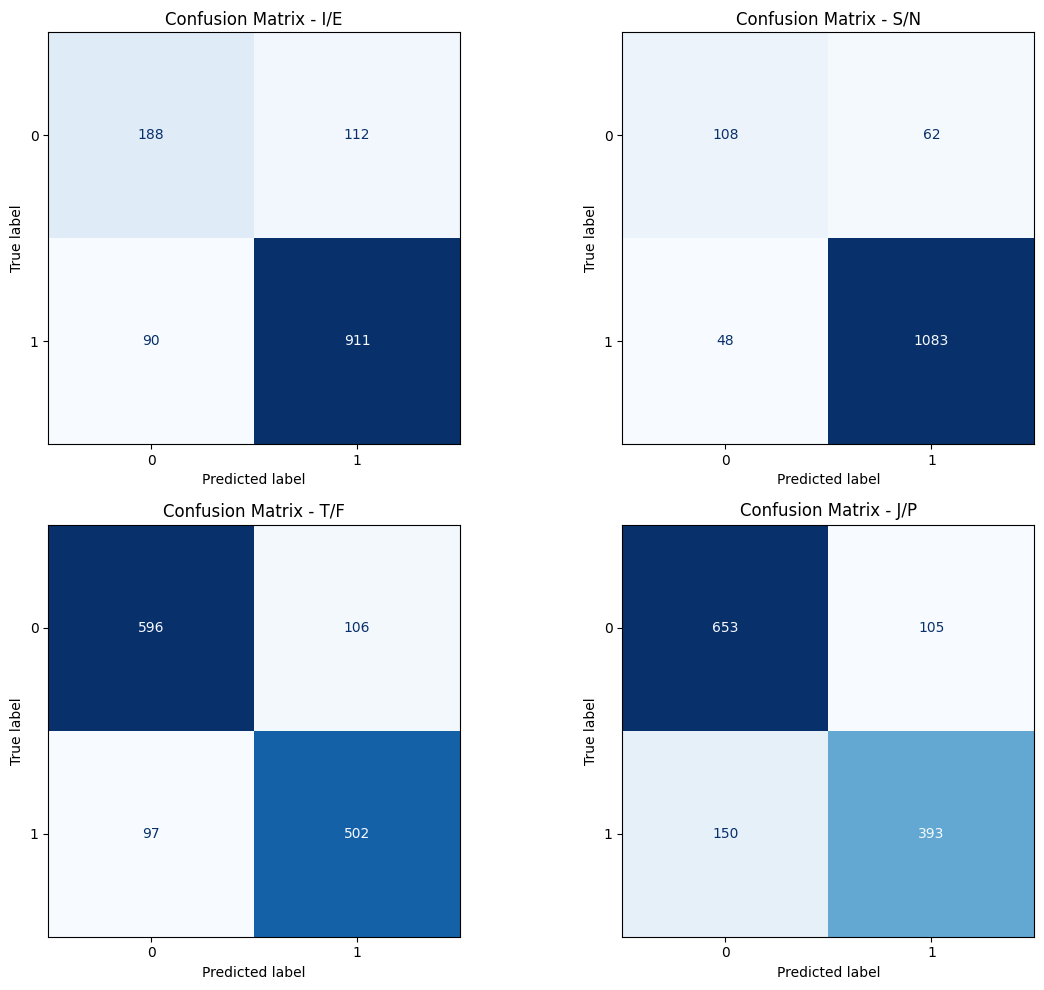

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
labels = ["I/E", "S/N", "T/F", "J/P"]

for i, col in enumerate(y_valid.columns):
    cm = confusion_matrix(y_valid[col], y_pred_svm[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"Confusion Matrix - {labels[i]}")

plt.tight_layout()
plt.show()

#### Predict kiye gaye probability distribution
LinearSVC mein `predict_proba` nahi hota, sirf `decision_function` hota hai
=> hum decision_function ko normalize karte hain taakay probability ka andaza lagaya ja sakay

In [41]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

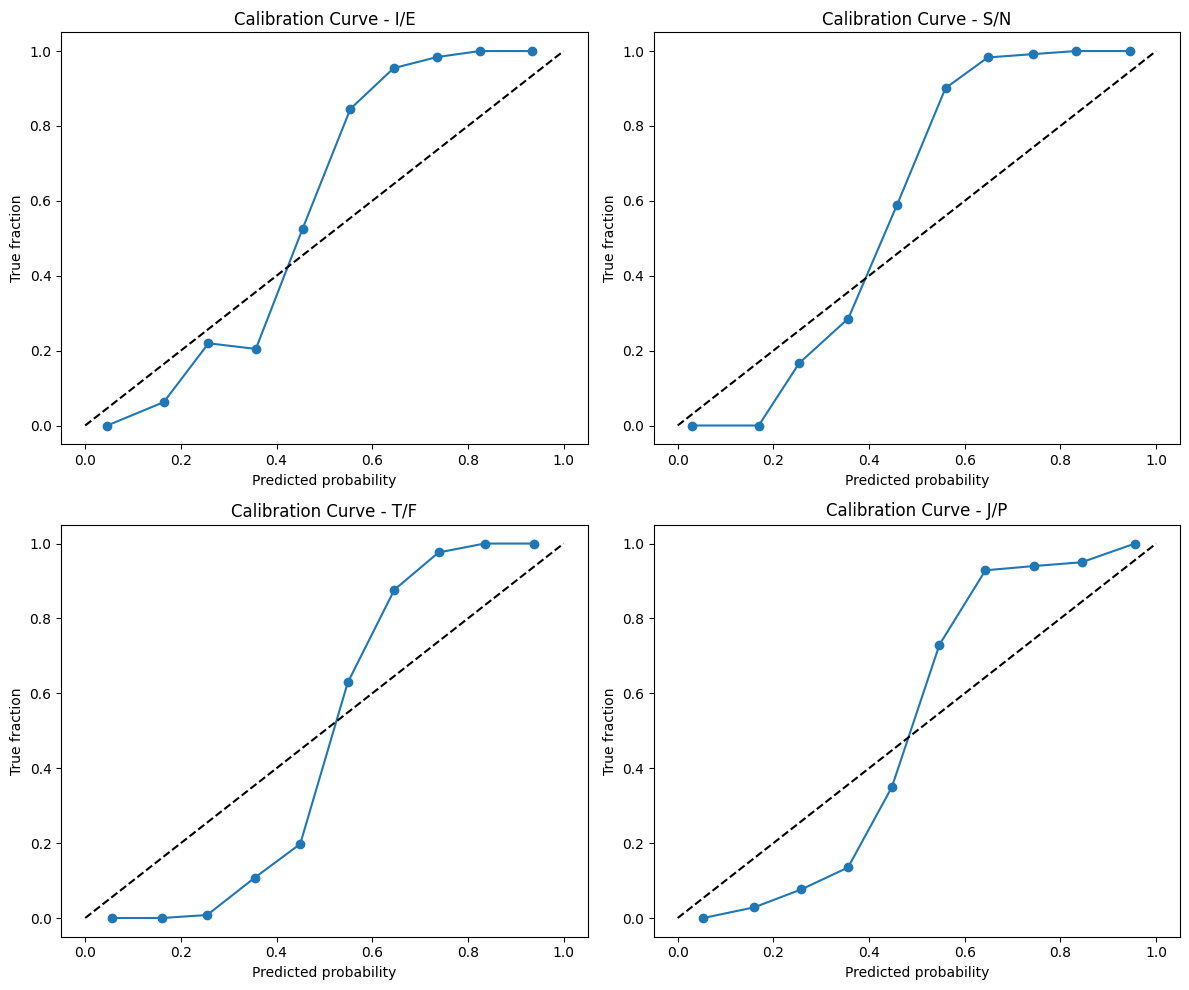

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, col in enumerate(y_valid.columns):
    scores = svm_clf.estimators_[i].decision_function(X_valid_word)
    probs = MinMaxScaler().fit_transform(scores.reshape(-1, 1)).ravel()
    frac_pos, mean_pred = calibration_curve(y_valid[col], probs, n_bins=10)

    axes[i].plot(mean_pred, frac_pos, marker="o", label="SVM")
    axes[i].plot([0, 1], [0, 1], "k--")
    axes[i].set_title(f"Calibration Curve - {labels[i]}")
    axes[i].set_xlabel("Predicted probability")
    axes[i].set_ylabel("True fraction")

plt.tight_layout()
plt.show()


Macro-F1 50 posts ke saath: 0.7957
Macro-F1 10 posts ke saath: 0.7178
Macro-F1 1 posts ke saath: 0.5827


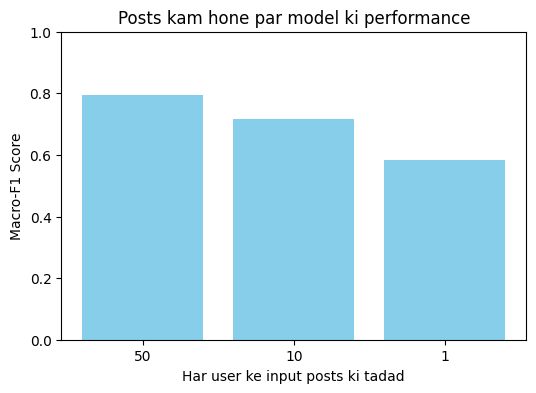

In [43]:
# Function Macro-F1 calculate karne ke liye jab posts ki limit ho
def evaluate_with_limited_posts(X_raw, y, limit_posts, vectorizer, model, X_full_vec=None):
    """
    X_raw: asli data (Series, har user list of posts ya gop text hai)
    y: labels
    limit_posts: posts ki limit (ya 'full')
    vectorizer: TF-IDF
    model: train hua classifier
    X_full_vec: pehle se vectorize kiya hua data ('full' ke liye)
    """
    if limit_posts == "full":
        # Test set ke liye pehle se tayyar vector use karein
        X_vec = X_full_vec
    else:
        X_limited = []
        for posts in X_raw:
            if isinstance(posts, list):
                subset = posts[:limit_posts]
                joined = " ".join(subset)
            else:
                # Agar text pehle se gop hai, toh words ke mutabiq cut karein (posts * 20 words)
                words = posts.split()[:limit_posts * 20]
                joined = " ".join(words)
            X_limited.append(joined)
        X_vec = vectorizer.transform(X_limited)

    # Predict karein
    y_pred = model.predict(X_vec)

    # 4 axes par average Macro-F1 score nikaalein
    scores = []
    for i in range(4):
        scores.append(f1_score(y.iloc[:, i], y_pred[:, i], average="macro"))
    return sum(scores) / 4


# === Robustness Test ===
limits = [50, 10, 1]
f1_results = {}

for k in limits:
    f1_results[k] = evaluate_with_limited_posts(
        X_test, y_test, k, tfidf_word, svm_clf, X_full_vec=X_test_word
    )
    print(f"Macro-F1 {k} posts ke saath: {f1_results[k]:.4f}")

# --- Graph Banayein ---
plt.figure(figsize=(6,4))
plt.bar([str(k) for k in limits], f1_results.values(), color="skyblue")
plt.xlabel("Har user ke input posts ki tadad")
plt.ylabel("Macro-F1 Score")
plt.title("Posts kam hone par model ki performance")
plt.ylim(0,1)
plt.show()

In [44]:
def show_top_features(vectorizer, clf, axis_name, top_n=10):
    """
    Ek axis (I/E, S/N, T/F, J/P) ke liye sab se aham alfaz (features) dikhayein.
    clf: MultiOutputClassifier ke andar mojud LogisticRegression ya LinearSVC estimator
    """
    feature_names = np.array(vectorizer.get_feature_names_out())
    coef = clf.coef_[0]  # binary hone ki wajah se sirf ek coefficient vector hota hai

    top_pos_idx = np.argsort(coef)[-top_n:]   # bade positive coefficients → class 1 ki taraf jhukaao
    top_neg_idx = np.argsort(coef)[:top_n]    # chhote negative coefficients → class 0 ki taraf jhukaao

    print(f"\n=== Axis {axis_name} ke liye top features ===")
    print("Class 1 (+):", feature_names[top_pos_idx])
    print("Class 0 (-):", feature_names[top_neg_idx])


# Logistic Regression ke saath misaal (example)
for i, axis in enumerate(["I/E", "S/N", "T/F", "J/P"]):
    show_top_features(tfidf_word, log_reg_clf.estimators_[i], axis, top_n=10)


=== Axis I/E ke liye top features ===
Class 1 (+): ['music' 'istp' 'infjs' 'isfp' 'intps' 'infps' 'intj' 'intp' 'infj' 'infp']
Class 0 (-): ['enfp' 'entp' 'entj' 'entps' 'enfps' 'enfj' 'estp' 'ne' 'enfjs' 'fun']

=== Axis S/N ke liye top features ===
Class 1 (+): ['intps' 'intjs' 'infjs' 'infps' 'entp' 'enfp' 'intp' 'infj' 'intj' 'infp']
Class 0 (-): ['istp' 'isfp' 'isfj' 'istj' 'isfps' 'estp' 'istps' 'isfjs' 'rant' 'esfjs']

=== Axis T/F ke liye top features ===
Class 1 (+): ['entps' 'shit' 'intjs' 'istj' 'entj' 'istp' 'intps' 'entp' 'intj' 'intp']
Class 0 (-): ['infp' 'infj' 'enfp' 'feel' 'love' 'infps' 'infjs' 'isfp' 'feeling'
 'isfj']

=== Axis J/P ke liye top features ===
Class 1 (+): ['plan' 'entj' 'istj' 'enfj' 'isfj' 'intjs' 'ni' 'infjs' 'intj' 'infj']
Class 0 (-): ['infp' 'intp' 'enfp' 'entp' 'infps' 'istp' 'intps' 'ne' 'entps' 'isfp']


# STEP 4: PREPARATION FOR UI
Akhir mein, hum apna best model (SVM) aur Vectorizer save karenge taake isay baad mein kisi Web App ya UI mein use kar saken.

In [45]:
OUTPUT_MODEL_DIR = "/content/models"
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)

joblib.dump(tfidf_word, os.path.join(OUTPUT_MODEL_DIR, "tfidf_vectorizer.pkl"))

joblib.dump(svm_clf, os.path.join(OUTPUT_MODEL_DIR, "svm_model.pkl"))
print("✅ Saved TF-IDF vectorizer and SVM model to:", OUTPUT_MODEL_DIR)

✅ Saved TF-IDF vectorizer and SVM model to: /content/models


In [46]:
def binary_to_mbti(vec):
    mapping = [
        ("I", "E"),
        ("N", "S"),
        ("T", "F"),
        ("J", "P")
    ]
    return "".join([mapping[i][0] if val == 1 else mapping[i][1] for i, val in enumerate(vec)])
print(binary_to_mbti([1,1,0,0]))  # => INTJ
print(binary_to_mbti([0,0,1,1]))  # => ESFP

INFP
ESTJ


In [47]:
mapping_dict = {}
import itertools
idx = 0
for ie in [0,1]:
    for sn in [0,1]:
        for tf in [0,1]:
            for jp in [0,1]:
                mbti = binary_to_mbti([ie, sn, tf, jp])
                mapping_dict[idx] = {"binary":[ie, sn, tf, jp], "mbti":mbti}
                idx += 1

mapping_path = os.path.join(OUTPUT_MODEL_DIR, "mbti_mapping.json")
with open(mapping_path, "w") as f:
    json.dump(mapping_dict, f, indent=2)
print("✅ Saved MBTI mapping to:", mapping_path)

✅ Saved MBTI mapping to: /content/models/mbti_mapping.json


In [48]:
loaded_tfidf = joblib.load(os.path.join(OUTPUT_MODEL_DIR, "tfidf_vectorizer.pkl"))
loaded_svm = joblib.load(os.path.join(OUTPUT_MODEL_DIR, "svm_model.pkl"))
sample_text = "I enjoy deep conversations about philosophy and science."
sample_vec = loaded_tfidf.transform([sample_text])
pred_binary = loaded_svm.predict(sample_vec)[0]
pred_mbti = binary_to_mbti(pred_binary)
print("Sample:", sample_text)
print("Predicted binary:", pred_binary)
print("Predicted MBTI:", pred_mbti)

Sample: I enjoy deep conversations about philosophy and science.
Predicted binary: [1 1 1 1]
Predicted MBTI: INTJ
